## SHAP

In [18]:
import os
import pickle
import torch
from model import DelphiConfig, Delphi
from tqdm import tqdm
import pandas as pd
import numpy as np
import textwrap
import warnings


import matplotlib.pyplot as plt
%config InlineBackend.figure_format='retina'

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams.update({'axes.grid': True,
                     'grid.linestyle': ':',
                     'axes.spines.bottom': False,
          'axes.spines.left': False,
          'axes.spines.right': False,
          'axes.spines.top': False})
plt.rcParams['figure.dpi']= 72
plt.rcParams['pdf.fonttype'] = 42

delphi_labels = pd.read_csv('delphi_labels_chapters_colours_icd.csv')
delphi_labels = pd.read_csv('delphi_labels_chapters_colours_icd_with_hla4d.csv')
labels = pd.read_csv("data/ukb_real_data_4digit/labels.csv", header=None, sep="\t")

## Load model

In [19]:
import mlflow
from pathlib import Path
import re

In [20]:
# This is just a workaround, the SHAP file should be an artifact!
def get_runid_from_shapfile():
    runid = [ x.split("_")[-1].split(".")[0] for x in os.listdir() if "shap_values" in x ][0]
    return runid

runid = get_runid_from_shapfile()
run_data = mlflow.get_run(runid)

In [21]:
client = mlflow.tracking.MlflowClient()

In [22]:
checkpoint_dir = 'checkpoints'
artifacts = client.list_artifacts(runid, path=Path(run_data.info.artifact_uri) / checkpoint_dir)

In [23]:
ckpt_files = [f for f in artifacts if f.path.startswith(f"{checkpoint_dir}/best_ckpt__{runid}__")]

step_ckpts = []

for f in ckpt_files:
    match = re.search(rf"best_ckpt__{re.escape(runid)}__(\d+)\.pt", f.path)
    if match:
        step = int(match.group(1))
        step_ckpts.append((step, f.path))

In [24]:
ckpt_path = run_data.info.artifact_uri + "/" + ckpt_files[0].path

In [25]:
device = 'cuda' # examples: 'cpu', 'cuda', 'cuda:0', 'cuda:1', etc.
seed = 1337

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cuda.matmul.allow_tf32 = True # allow tf32 on matmul
torch.backends.cudnn.allow_tf32 = True # allow tf32 on cudnn

device_type = 'cuda' if 'cuda' in device else 'cpu'
dtype = getattr(torch, 'float32') 

In [26]:
model = Delphi.from_checkpoint(ckpt_path)

number of parameters: 8.75M


## Load data

In [27]:
from utils import get_batch, get_p2i

In [28]:
train = np.fromfile('data/ukb_real_data_4digit/train.bin', dtype=np.uint32).reshape(-1,3)
val = np.fromfile('data/ukb_real_data_4digit/val.bin', dtype=np.uint32).reshape(-1,3)

train_p2i = get_p2i(train)
val_p2i = get_p2i(val)

In [29]:
person = [('Male', 0),
 ('B01 (varicella [chickenpox])',2),
 ('L20 (atopic dermatitis)',3),
 ('Healthy', 5),
 ('Healthy', 10),
 ('Healthy', 15),
 ('Healthy', 20),
 ('G43 (migraine)', 20),
 ('E73 (lactose intolerance)',21),
 ('B27 (infectious mononucleosis)',22),
 ('Healthy', 25),
 ('J11 (influenza, virus not identified)',28),
 ('Healthy', 30),
 ('Healthy', 35),
 ('C25 Malignant neoplasm of pancreas',38),
 ('Healthy', 40),
 ('Smoking_low', 41),
 ('BMI_mid', 41),
 ('Alcohol_high', 41),
 ('Healthy', 42),
]
person = [(a, b * 365.25) for a,b in person] 

### Individual SHAP values

In [30]:
id_to_token = labels.to_dict()[0]
token_to_id = {v:k for k, v in id_to_token.items()}

def tokens_to_ids(tokens):
    return [token_to_id[t] for t in tokens]

def ids_to_tokens(ids):
    return [id_to_token[int(id_)] for id_ in ids]

def split_person(p):
    tokens = [i[0] for i in p]
    ages = [i[1] for i in p]
    return tokens, ages

In [31]:
def get_person(idx):
    x, y, _, time = get_batch([idx], val, val_p2i,  
              select='left', block_size=48, 
              device=device, padding='random')
    x, y = x[y > -1], y[y > -1]
    person = []
    for token_id, date in zip(x, y):
        person.append((id_to_token[token_id.item()], date.item()))
    return person, y, time[0][-1]

In [32]:
from itertools import takewhile
from utils import shap_custom_tokenizer, shap_model_creator
import shap

person_to_process = get_person(137)[0]
person_to_process = person
diseases_of_interest = [1269, 46, 95, 1168, 374, 173, 214, 305, 505, 584]

person_tokens, person_ages = split_person(person_to_process)
person_tokens_ids = tokens_to_ids(person_tokens)

masker = shap.maskers.Text(shap_custom_tokenizer, output_type='str', mask_token='10000', collapse_mask_token=False)
model_shap = shap_model_creator(model, diseases_of_interest, person_tokens_ids, person_ages, device)
explainer = shap.Explainer(model_shap, masker, output_names=delphi_labels['name'].values[diseases_of_interest])

shap_values = explainer([' '.join(list(map(lambda x: str(token_to_id[x]), person_tokens)))])
shap_values.data = np.array([list(map(lambda x: f"{delphi_labels['name'].values[token_to_id[x[0]]]}({x[1]/365:.1f} years) ", person_to_process))])

RuntimeError: CUDA error: CUDA driver version is insufficient for CUDA runtime version
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Device-side assertions were explicitly omitted for this error check; the error probably arose while initializing the DSA handlers.

In [33]:
out = shap.plots.text(shap_values, display=True)

NameError: name 'shap_values' is not defined

In [34]:
from plotting import waterfall

with plt.style.context('default'):
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['figure.dpi'] = 150
    plt.rcParams['font.size'] = 4
    waterfall(shap_values[0, ..., 0], max_display=7, show=False, ages=person_ages)
    plt.gca().set_title('Impact of diseases on mortality', fontweight=1, size=18)
    plt.show()

NameError: name 'shap_values' is not defined

## Pre-computed many cases

The small synthetic dataset is not enough to properly run following part; if you have access to the full dataset, the `shap-agg-eval.py` to evaluate SHAP values for the entire dataset.

In [35]:
import os
import pickle
import torch
from model import DelphiConfig, Delphi
from tqdm import tqdm
import pandas as pd
import numpy as np
import textwrap
import warnings


import matplotlib.pyplot as plt
%config InlineBackend.figure_format='retina'

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams.update({'axes.grid': True,
                     'grid.linestyle': ':',
                     'axes.spines.bottom': False,
          'axes.spines.left': False,
          'axes.spines.right': False,
          'axes.spines.top': False})
plt.rcParams['figure.dpi']= 72
plt.rcParams['pdf.fonttype'] = 42

delphi_labels = pd.read_csv('delphi_labels_chapters_colours_icd.csv')
delphi_labels = pd.read_csv('delphi_labels_chapters_colours_icd_with_hla4d.csv')
labels = pd.read_csv("data/ukb_real_data_4digit/labels.csv", header=None, sep="\t")

In [36]:
import pickle

SHAP_FILE = f'shap_values_half_{runid}.pkl'

with open(SHAP_FILE, 'rb') as f:
    shap_pkl = pickle.load(f)    

In [37]:
all_tokens = shap_pkl['tokens']
all_values = shap_pkl['values']

In [38]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

df_shap = pd.DataFrame(all_values)
df_shap['token'] = all_tokens.astype('int')

In [39]:
token_count_dict = df_shap['token'].value_counts().sort_index().to_dict()

N_min = 5

columns_more_N = [c for c in df_shap.columns if c == 1269 or (c in token_count_dict and token_count_dict[c] >= N_min)]
df_shap_agg = df_shap[df_shap['token'].apply(lambda x: token_count_dict[x] > N_min)].groupby('token').mean()

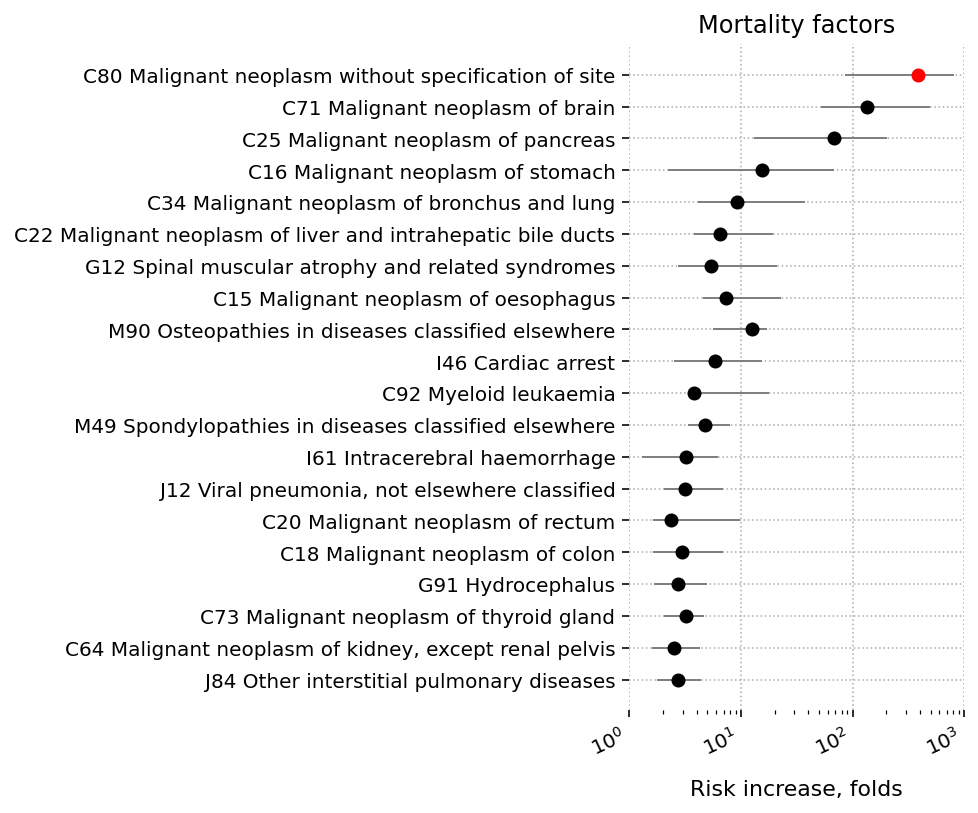

In [40]:
import matplotlib.pyplot as plt
import numpy as np

N = 1269 + 359
n_first = 20
positive = True

# Determine the most probable tokens and values based on the condition
if positive:
    most_probable_tokens = df_shap_agg[N].nlargest(n_first).index[::-1]
    most_probable_values = df_shap_agg[N].nlargest(n_first).values[::-1]
else:
    most_probable_tokens = df_shap_agg[N].nsmallest(n_first).index[::-1]
    most_probable_values = df_shap_agg[N].nsmallest(n_first).values[::-1]

# Prepare the data
df_shap_selected_melted = df_shap[df_shap['token'].isin(most_probable_tokens)][[N, 'token']].reset_index(drop=True).melt(id_vars=['token'])
df_shap_selected_melted['token'] = df_shap_selected_melted['token'].map(id_to_token)
df_shap_selected_melted['value'] = np.exp(df_shap_selected_melted['value'])

# Create a figure and axis
plt.figure(figsize=(3, 6), facecolor='w')
ax = plt.gca()

# Map most_probable_tokens to their string representations
token_strings = [id_to_token[token] for token in most_probable_tokens]

# Plot median and quartiles for each token
for i, token in enumerate(token_strings):
    data = df_shap_selected_melted[df_shap_selected_melted['token'] == token]['value']
    median = np.median(data)
    quartiles = np.percentile(data, [25, 75])
    
    # Plot median
    if i == len(token_strings) - 1:
        ax.plot(median, i, 'o', color='red', zorder=3)
    else:
        ax.plot(median, i, 'o', color='black', zorder=3)
    
    # Plot quartiles
    ax.hlines(i, quartiles[0], quartiles[1], color='gray', linestyles='solid', linewidth=1)

# Set title and labels
positive_text = "" if positive else "not "
title_text = f'Mortality factors'
plt.title(title_text)
plt.yticks(range(len(token_strings)), token_strings)

# Adjust x-ticks orientation
plt.xticks(rotation=25, ha='right')
plt.xscale('log')
plt.xlim(1, 1000)
plt.xlabel('Risk increase, folds', size=11, labelpad=10)

# Show the plot
plt.show()

In [41]:
from ipywidgets import interact
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np

In [44]:
@interact
def show_shap_values(disease=widgets.Combobox(options=[ x for x in labels.loc[df_shap_agg.index][0].to_list() if "HLA" not in x], value="Male")):
  
    N = labels.index[labels[0] == disease][0]

    print(disease)

    n_first = 40
    positive = True
    
    # Determine the most probable tokens and values based on the condition
    if positive:
        most_probable_tokens = df_shap_agg.loc[N].argsort()[::-1][:n_first][::-1]
    else:
        most_probable_tokens = df_shap_agg.loc[N].argsort()[:n_first][::-1]
    
    
    # Prepare the data
    df_shap_selected_melted = df_shap[df_shap['token'] == N][[*most_probable_tokens, 'token']].reset_index(drop=True).melt(id_vars=['token'])
    df_shap_selected_melted['token'] = df_shap_selected_melted['token'].map(id_to_token)
    df_shap_selected_melted['variable'] = df_shap_selected_melted['variable'].map(id_to_token)
    
    df_shap_selected_melted['value'] = np.exp(df_shap_selected_melted['value'])
    # print(df_shap_selected_melted)
        
    # Create a figure and axis
    plt.figure(figsize=(3, 10), facecolor='w')
    ax = plt.gca()
    
    # Map most_probable_tokens to their string representations
    token_strings = [id_to_token[token] for token in most_probable_tokens]
    
    # Plot median and quartiles for each token
    for i, token in enumerate(token_strings):
        data = df_shap_selected_melted[df_shap_selected_melted['variable'] == token]['value']
        median = np.median(data)
        quartiles = np.percentile(data, [25, 75])
        
        # Plot median
        ax.plot(median, i, 'o', color='red' if (i==len(token_strings)-1) else 'black', zorder=3)
        
        # Plot quartiles
        ax.hlines(i, quartiles[0], quartiles[1], color='gray', linestyles='solid', linewidth=1)
    
    # Set title and labels
    title_text = labels.loc[N][0]
    plt.title(title_text)
    plt.yticks(range(len(token_strings)), token_strings)
    
    # Adjust x-ticks orientation
    plt.xticks(rotation=25, ha='right')
    plt.xscale('log')
    plt.xlim(1, 11)
    plt.xlabel('Risk increase, folds', size=11, labelpad=10)
    
    # Show the plot
    plt.show()

interactive(children=(Combobox(value='Male', description='disease', options=('No event', 'Female', 'Male', 'BM…

### Influence vs Predictability

In [45]:
df_shap_agg_sim = df_shap_agg[df_shap_agg.index].values[13:, 13:]
perm = np.arange(df_shap_agg_sim.shape[0])
np.random.shuffle(perm)
df_shap_agg_sim = df_shap_agg_sim[perm][:, perm]

In [46]:
df_shap_agg_sim_x = df_shap_agg_sim[np.triu_indices(df_shap_agg_sim.shape[0], 1)]
df_shap_agg_sim_y = df_shap_agg_sim.T[np.triu_indices(df_shap_agg_sim.shape[0], 1)]
corrcoef = np.corrcoef(df_shap_agg_sim_y, df_shap_agg_sim_x)[0, 1]

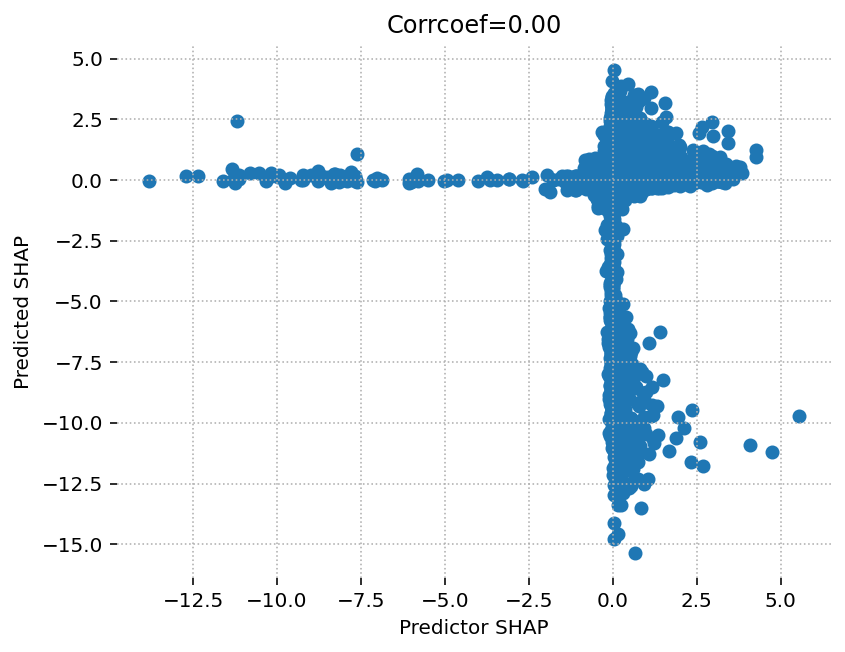

In [47]:
from matplotlib.colors import LogNorm

ddf = pd.DataFrame({'x': df_shap_agg_sim_x, 'y': df_shap_agg_sim_y})

plt.scatter(df_shap_agg_sim_x, df_shap_agg_sim_y)

plt.xlabel('Predictor SHAP')
plt.ylabel('Predicted SHAP')
plt.title(f'Corrcoef={corrcoef:.2f}')
plt.show()

#### Only within chapters

In [48]:
df_shap_agg_sim_x_all = []
df_shap_agg_sim_y_all = []
colours = []
coeffs = []
chapters = []

for g, df_ in delphi_labels.groupby('ICD-10 Chapter (short)'):
    if g in ['Sex', 'Smoking, Alcohol and BMI']:
        continue
    idxs = np.intersect1d(df_shap_agg.index.values, df_.index.values)
    df_shap_agg_sim = df_shap_agg.loc[idxs, idxs].values
    df_shap_agg_sim_x = df_shap_agg_sim[np.triu_indices(df_shap_agg_sim.shape[0], 1)]
    df_shap_agg_sim_y = df_shap_agg_sim.T[np.triu_indices(df_shap_agg_sim.shape[0], 1)]

    df_shap_agg_sim_x_all.append(df_shap_agg_sim_x)
    df_shap_agg_sim_y_all.append(df_shap_agg_sim_y)
    colours += [df_['color'].values[0]] * len(df_shap_agg_sim_x)
    chapters += [g] * len(df_shap_agg_sim_x)

    coef = np.corrcoef(df_shap_agg_sim_x, df_shap_agg_sim_y)[0, 1]
    if not np.isnan(coef):
        coeffs.append(coef)
    print(f'{g}\t {coef:.2f}')

df_shap_agg_sim_x = np.concatenate(df_shap_agg_sim_x_all)
df_shap_agg_sim_y = np.concatenate(df_shap_agg_sim_y_all)

Death	 nan
HLA	 0.00
I. Infectious Diseases	 0.33
II. Neoplasms	 0.43
III. Blood & Immune Disorders	 0.62
IV. Metabolic Diseases	 0.48
IX. Circulatory Diseases	 0.52
Technical	 nan
V. Mental Disorders	 0.61
VI. Nervous System Diseases	 0.59
VII. Eye Diseases	 0.30
VIII. Ear Diseases	 0.72
X. Respiratory Diseases	 0.55
XI. Digestive Diseases	 0.66
XII. Skin Diseases	 0.40
XIII. Musculoskeletal Diseases	 0.50
XIV. Genitourinary Diseases	 0.61
XV. Pregnancy & Childbirth	 0.15
XVI. Perinatal Conditions	 nan
XVII. Congenital Abnormalities	 0.62


/homes/bonazzola/miniforge3/envs/delphi/lib/python3.11/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/homes/bonazzola/miniforge3/envs/delphi/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/homes/bonazzola/miniforge3/envs/delphi/lib/python3.11/site-packages/numpy/lib/function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/homes/bonazzola/miniforge3/envs/delphi/lib/python3.11/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/homes/bonazzola/miniforge3/envs/delphi/lib/python3.11/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/homes/bonazzola/miniforge3/envs/delphi/lib/python3.11/site-packages/numpy/lib/function_bas

In [49]:
color_mapping = {}
for ch, col in delphi_labels[['ICD-10 Chapter (short)', 'color']].values:
    color_mapping[ch] = col

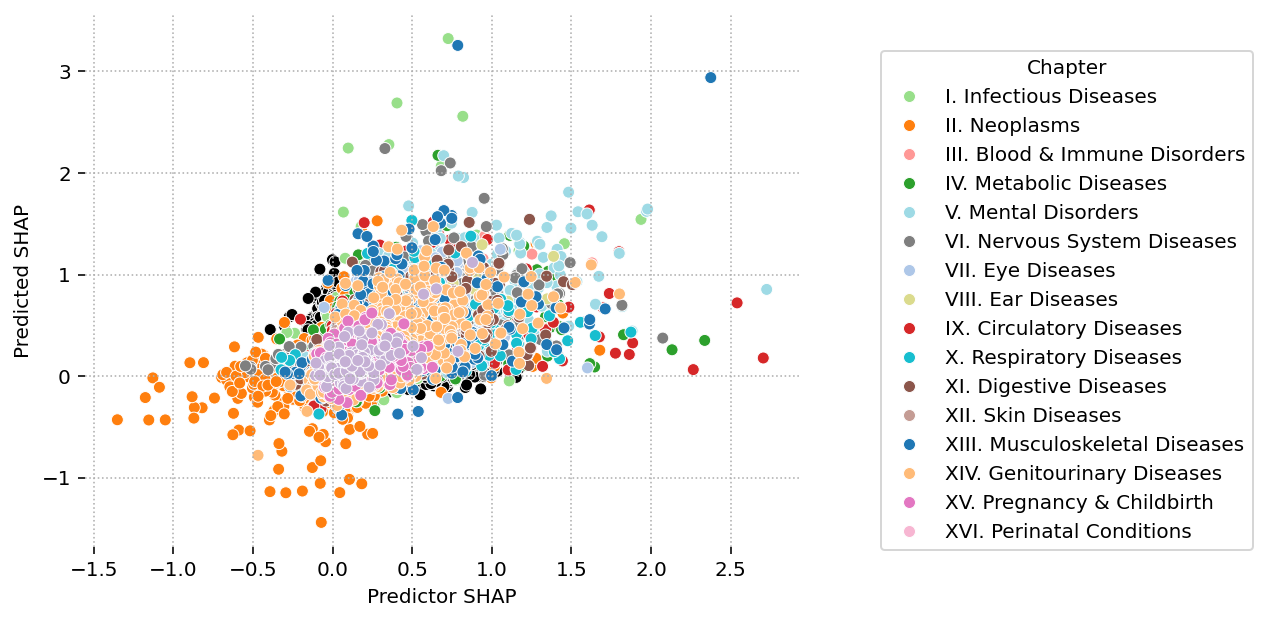

In [62]:
from matplotlib.colors import LogNorm

order = ['I. Infectious Diseases', 'II. Neoplasms',
       'III. Blood & Immune Disorders', 'IV. Metabolic Diseases', 
       'V. Mental Disorders', 'VI. Nervous System Diseases',
       'VII. Eye Diseases', 'VIII. Ear Diseases', 'IX. Circulatory Diseases', 'X. Respiratory Diseases',
       'XI. Digestive Diseases', 'XII. Skin Diseases',
       'XIII. Musculoskeletal Diseases', 'XIV. Genitourinary Diseases',
       'XV. Pregnancy & Childbirth', 'XVI. Perinatal Conditions',]

ddf = pd.DataFrame({'x': df_shap_agg_sim_x, 'y': df_shap_agg_sim_y, 'c': colours, 'Chapter': chapters})

sns.scatterplot(data=ddf, x='x', y='y', hue='Chapter', 
           palette=color_mapping, hue_order=order)
plt.xlabel('Predictor SHAP')
plt.ylabel('Predicted SHAP')
plt.gca().legend_.set_bbox_to_anchor((1.1, 0.95))
plt.show()

###  Time-resolved SHAP analysis

In [63]:
from utils import get_batch

In [64]:
import textwrap
from tqdm import tqdm

def wrap(txt, width=30):
    segments = textwrap.wrap(txt, width)
    return '\n'.join(segments)

In [65]:
d = get_batch(range(len(np.unique(shap_pkl['people']))), val, val_p2i,  
              select='left', block_size=48, 
              device='cpu', padding='regular')

In [66]:
has_gender = torch.isin(d[0], torch.tensor([2, 3])).any(dim=1).numpy()
is_male = torch.isin(d[0], torch.tensor([3])).any(dim=1).numpy()
is_female = torch.isin(d[0], torch.tensor([2])).any(dim=1).numpy()

In [67]:
def get_person(idx):
    x, y, _, time = get_batch([idx], val, val_p2i,  
              select='left', block_size=48, 
              device=device, padding='regular')
    x, y = x[y > -1], y[y > -1]
    person = []
    for token_id, date in zip(x, y):
        person.append((id_to_token[token_id.item()], date.item()))
    return person, y, time[0][-1]

In [69]:
device = 'cuda'

In [76]:
shap_pkl

{'tokens': array([   1,  863, 1024, ...,  792,  798,  820]),
 'values': array([[ 4.106e-01, -1.860e-01, -8.408e-01, ...,  4.346e-01,  6.274e-01,
         -6.270e-01],
        [ 1.362e-01, -5.316e-02, -1.256e+00, ...,  1.329e-01,  1.667e-01,
         -5.337e-01],
        [-3.961e-02, -1.638e-03, -1.761e-01, ...,  4.874e-02, -6.659e-02,
         -5.130e-02],
        ...,
        [ 2.722e-01,  7.721e-03,  6.694e-01, ...,  7.788e-02,  3.494e-01,
         -3.210e-02],
        [ 4.299e-01,  1.376e-02,  8.931e-01, ...,  4.919e-01,  3.577e-01,
          7.819e-02],
        [ 4.883e-01,  8.202e-04,  7.974e-01, ...,  4.944e-01,  3.970e-01,
          1.696e-01]], dtype=float16),
 'times': array([13698., 11013.,  8601., ...,   385.,   385.,     0.], dtype=float32),
 'people': array([    3,     3,     3, ..., 50225, 50225, 50225])}

In [105]:
persons_lengths = []
ages = []
reg_times = []

for p in tqdm(np.unique(shap_pkl['people'])):
    pers = get_person(p)
    # print(pers[-1].item(), len(pers[0]))
    reg_time_idx = np.where(np.isin(tokens_to_ids(np.array(pers[0])[:, 0]), np.arange(4, 13+359)))[0]
    print(reg_time_idx)
    if len(reg_time_idx) > 0:
        reg_time = pers[0][reg_time_idx[0]][1]
    else:
        reg_time = -1

    reg_times += [reg_time] * len(pers[0])
    persons_lengths += [p] * len(pers[0])
    ages += [pers[-1].item()] * len(pers[0])

  2%|▏         | 125/5556 [00:00<00:08, 618.88it/s]

[24 25 26]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 32 33 34]
[ 0  1  2  3  4  5 29 30 31]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 32 33 34]
[ 0  1  2 25 26 27]
[ 0  1  2  3  4  5 27 28 29]
[ 0  1  2  3  4  5  6  7  8  9 10 11 28 29 30]
[ 0  1  2  3 31 32 33]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 31 32 33]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 37 38 39]
[ 0  1  2  3  4  5  6  7 30 31 32]
[15 16 17]
[ 0  1  2  3  4  5  6  7 33 34 35]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 17 32 33 34]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 36 37 38]
[0 1 2 3 4 5 6 7 8]
[ 0  1  2  3  4  5 30 31 32]
[ 0  1  2  3  4  5  6  7 33 34 35]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 41 42 43]
[ 0  1  2  3  4 35 36 37]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 34 35 36]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 42 43 44]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 38 39 40]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15

  4%|▍         | 249/5556 [00:00<00:08, 616.40it/s]

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 31 32 33]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 43 44]
[ 0  1  2  3  4  5 28 29 30]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 36 37 38]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 33 34 35]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 36 37 38]
[ 0  1  2  3  4  5  6  7  8  9 22 23 24]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 34 35 36]
[ 0  1  2  3  4  5  6  7  8  9 10 11 40 41 42]
[ 0  1  2  3  4  5  6  7 41 42 43]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 40 41 42]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 33 34 35]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 36 37 38]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 17 36 37 38]
[ 0  1  2  3  4  5  6  7  8  9 10 11 13 14 15 16 17 29 30]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 42 43 44]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 15 35 36 37]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12

  7%|▋         | 373/5556 [00:00<00:08, 617.06it/s]

...

[ 0  1  2  3  4 28 29]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 35 36 37]
[ 0  1  2  3  4  5  6  7  8  9 10 11 13 14 15 16 28 29]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 33 34 35]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 39 40 41]
[ 0  1  2  3  4  5 28 29 30]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 37 38 39]
[ 0  1  2  3 34 35 36]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 37 38 39]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 34 35 36]
[ 0  1  2  3  4  5  6  7  8  9 10 11 34 35 36]
[ 0  1  2  3  4 33 34 35]
[ 0  1  2 30 31 32]
[ 0  1  2 36 37 38]
[ 0  1  2  3  4  5 31 32 33]
[ 0  1  2  3 34 35 36]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 38 39 40]
[ 0  1  2  3  4  5 34 35 36]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 41 42 43]
[ 0  1  2  3  4 33 34 35]
[ 0  1  2  3  4  5  6 35 36 37]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 14 15 16 17 18 32 33]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 29 30 31]
[ 0  1  2  3 47]
[

100%|█████████▉| 5544/5556 [00:09<00:00, 601.66it/s]

[ 0  1  2  3  4  5  6  7  8 31 32 33]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 31 32 33]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 38 39 40]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 41 42 43]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 39 40 41]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 34 35 36]
[13 14 15]
[ 0  1  2 41 42 43]
[ 0  1  2  3  4  5  6  7  8 30 31 32]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 15 16 17 18 36 37]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 31 32 33]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 33 34 35]
[ 0  1  2  3  4  5  6  7  8  9 10 26 27 28]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 41 42 43]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 16 33 34 35]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 33 34 35]
[ 0  1  2 28 29 30]
[ 0  1  2  3  4  5  6 26 27 28]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 33 34 35]
[ 0  1  2  3  4 39 40 41]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 37

100%|██████████| 5556/5556 [00:09<00:00, 606.49it/s]

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 15 16 17 18 32 33]
[ 0  1  2  3  4  5  6  7  8  9 10 11 33 34 35]
[ 0  1  2  3  4 26 27 28]
[ 0  1  2  3  4 36 37 38]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 29 30 31]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 32 33 34]
[15 16 17]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 40 41 42]
[ 0  1  2  3  4  5  6  7  8 28 29 30]
[ 0  1  2  3  4 33 34 35]
[ 0  1  2  3  4  5  6 28 29 30]
[18 19 20]


In [106]:
assert len(ages) == len(df_shap), f"{len(ages)=} != {len(df_shap)=}"

AssertionError: len(ages)=253630 != len(df_shap)=288219

In [103]:
assert len(ages) == len(df_shap), f"{len(ages)=} != {len(df_shap)=}"

all_tokens = shap_pkl['tokens']
all_values = shap_pkl['values']
all_times = shap_pkl['times']

df_shap = pd.DataFrame(all_values)
df_shap['token'] = all_tokens
df_shap['time'] = all_times
df_shap['person'] = shap_pkl['people']
df_shap['age'] = np.array(ages) / 365.25
df_shap['reg_time_years'] = np.array(reg_times) / 365.25

df_shap['Time, years'] = df_shap['time'] / 365.25
df_shap['age_at_token'] = df_shap['age'] - df_shap['time'] / 365.25

df_shap = df_shap[df_shap['reg_time_years'] > 0]

AssertionError: len(ages)=253630 != len(df_shap)=288219

In [ ]:
token_count_dict = df_shap['token'].value_counts().sort_index().to_dict()

In [ ]:
def filter_bins(x, y, n=5, grid_size=3):
    '''Filter out regions wiht few data points'''
    x, y = np.array(x), np.array(y)
    
    bin_edges = np.arange(np.min(x), np.max(x), grid_size)        
    bin_indices = np.digitize(x, bin_edges)

    bin_counts = np.array([np.sum(bin_indices == i) for i in range(1, len(bin_edges)+1)])
    valid_bins = np.where(bin_counts >= n)[0] + 1

    valid_indices = np.isin(bin_indices, valid_bins)
    x_filtered = x[valid_indices]
    y_filtered = y[valid_indices]

    return x_filtered, y_filtered


In [ ]:
def bins_avg(x, y, grid_size=3):
    '''Filter out regions wiht few data points'''
    x, y = np.array(x), np.array(y)
    
    bin_edges = np.arange(np.min(x), np.max(x), grid_size)

    bin_indices = np.digitize(x, bin_edges)
    bin_avgs = np.array([y[bin_indices == i].mean() for i in range(1, len(bin_edges)+1)])

    return bin_edges, bin_avgs


In [ ]:
import statsmodels.api as sm

def lowess_regression(x, y, delta=0):
    """
    Perform Lowess regression on two numpy arrays, x and y, 
    and return function values over a fixed grid.

    Parameters:
    x (numpy array): Independent variable data.
    y (numpy array): Dependent variable data.

    Returns:
    numpy array: Computed Lowess values on a fixed grid.
    """

    x, y = np.array(x), np.array(y)
    grid = np.linspace(np.min(x), np.max(x), 100)
    
    lowess = sm.nonparametric.lowess(y, x, delta=delta)
    lowess_on_grid = np.interp(grid, lowess[:, 0], lowess[:, 1])

    return grid, lowess_on_grid

In [ ]:
idxs_of_interest = [1188, 46, 1168, 305]

palette_faint = [sns.color_palette("Paired")[0], sns.color_palette("Paired")[2], sns.color_palette("Paired")[4]]
palette_bright = [sns.color_palette("Paired")[1], sns.color_palette("Paired")[3], sns.color_palette("Paired")[5]]

# Create a 3x3 grid for subplots
fig, axs = plt.subplots(2, 2, figsize=(4, 3.8), sharey=True, sharex=False)
axs = axs.flatten()

for ax, idx in zip(axs, idxs_of_interest):
        traits = labels.loc[[idx]]
        df_trait = df_shap[df_shap['token'].isin(traits.index)].copy()
        df_trait['Time, years'] = df_trait['time'] / 365.25
        df_trait['Bracket'] = df_trait['token'].map(id_to_token)
        df_trait[1269] = np.exp(df_trait[1269])
        
        # Scatterplot configuration
        sns.scatterplot(data=df_trait, x='Time, years', y=1269, ax=ax, alpha=1, color='#DBE7F0', label=wrap(id_to_token[idx], width=15), 
                        legend=None, s=3, rasterized=True)
        ax.set_title(wrap(delphi_labels.loc[idx, 'name'], width=60), size=7)

        # Regression plot configuration
        x, y = df_trait['Time, years'], df_trait[1269]
        n = 3

        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            x, y = bins_avg(x, y, grid_size=n)
        
        ax.plot(x, y, color=palette_bright[0], linewidth=0.8)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_yscale('log')
        # ax.tick_params(length=1, width=0.5, labelsize=4, grid_alpha=0.65, grid_linewidth=0.45)
        # ax.tick_params(which='minor', length=0.5, width=0.3, labelsize=4, grid_alpha=0.65, grid_linewidth=0.45)
        ax.set_xlim(0, 10)


        # ax.set_xlim(None, [70, 20, 40][col]) 

ax.set_ylim(0.5, 500)
ax.set_xlim(0, 10)
plt.figtext(0.525, -0.02, 'Time after diagnosis, years', size=7, ha='center')
plt.figtext(-0.02, 0.5, 'Mortality increase, folds', size=7, ha='center', va='center', rotation=90)

plt.tight_layout(pad=1.05)  # Adjust the rect parameter as needed

plt.show()

In [ ]:
tokens_of_interest = [46, 95, 1168, 1188, 173, 214, 305, 505, 584, 1269]
n_groups = len(tokens_of_interest) // 5

for num_g, token_group in enumerate(np.array_split(tokens_of_interest, n_groups)):

    fig, axs = plt.subplots(1, 5, figsize=(12, 2), sharey=True)
    
    for num, (ax, token_id) in enumerate(zip(axs.flatten(), token_group)):
        df_trait = df_shap[df_shap['token'] == token_id].copy()
        df_trait[1269] = np.exp(df_trait[1269].values)
        df_trait['Time, years'] = df_trait['time'] / 365.25
        df_trait = df_trait.head(2000)
        if len(df_trait) < 2:
            continue

        sns.scatterplot(data=df_trait, x='Time, years', y=1269, ax=ax, color=palette_faint[0], alpha=0.7, rasterized=True)

        x, y = df_trait['Time, years'], df_trait[1269]
        n = 3

        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            x, y = bins_avg(x, y, grid_size=n)
        
        ax.plot(x, y, color=palette_bright[0], linewidth=1.5)

        ax.set_ylim(0.5, 500)
        ax.set_xlim(0.1, 10)
        ax.set_ylabel('Impact on mortality');
        ax.set_title(wrap(id_to_token[token_id]) + f' {token_id}', size=9)
        # ax.set_xscale('log')
    
    ax.set_yscale('log')
    plt.show()


## Interaction heatmap

In [ ]:
N_min = 5

token_count_dict_below_5y = df_shap[df_shap['Time, years'] < 5]['token'].value_counts().sort_index().to_dict()
token_count_dict_over_10y = df_shap[df_shap['Time, years'] > 10]['token'].value_counts().sort_index().to_dict()

for d in [token_count_dict_below_5y, token_count_dict_over_10y]:
    for i in range(1300):
        if i not in d:
            d[i] = 0

columns_more_N = [c for c in df_shap.columns if c == 1269 or(c in token_count_dict_below_5y and token_count_dict_below_5y[c] >= N_min and 
                                                             c in token_count_dict_over_10y and token_count_dict_over_10y[c] >= N_min)]
df_shap_agg_below_5y = df_shap[df_shap['token'].apply(lambda x: x in columns_more_N) * (df_shap['Time, years'] < 5)].groupby('token').mean()[columns_more_N]
df_shap_agg_over_10y = df_shap[df_shap['token'].apply(lambda x: x in columns_more_N) * (df_shap['Time, years'] > 10)].groupby('token').mean()[columns_more_N]

In [ ]:
def get_tick_coords(arr):
    return np.where(arr[1:] != arr[:-1])[0]

In [ ]:
from matplotlib.colors import LogNorm

cur_df = df_shap_agg_below_5y

new_death_rows = 0
for c in range(1269+1, 1269+new_death_rows+1):
    cur_df[c] = cur_df[1269]
delphi_labels = pd.read_csv("delphi_labels_chapters_colours_icd.csv", index_col=0)
death_df = delphi_labels[delphi_labels['ICD-10 Chapter (short)']=="Death"].sample(new_death_rows, replace=True)
death_df['name'] = death_df['name'].apply(lambda x: x + str(np.random.randint(0, 100000)))
death_df.index = pd.Index(range(1269+1, 1269+new_death_rows+1))
delphi_labels = pd.concat([delphi_labels, death_df])

to_exclude_predicted = ['Technical', 'Smoking, Alcohol and BMI', 'Sex', 'XVI. Perinatal Conditions']
to_exclude_predictor = ['Technical', 'Smoking, Alcohol and BMI', 'Sex', 'XVI. Perinatal Conditions', 'Death']

chapter_order = ['I. Infectious Diseases', 'II. Neoplasms',
                   'III. Blood & Immune Disorders', 'IV. Metabolic Diseases', 
                   'V. Mental Disorders', 'VI. Nervous System Diseases',
                   'VII. Eye Diseases', 'VIII. Ear Diseases', 'IX. Circulatory Diseases', 'X. Respiratory Diseases',
                   'XI. Digestive Diseases', 'XII. Skin Diseases',
                   'XIII. Musculoskeletal Diseases', 'XIV. Genitourinary Diseases',
                   'XV. Pregnancy & Childbirth', 'XVI. Perinatal Conditions',
                   'XVII. Congenital Abnormalities', 'Death']


to_exclude_predicted_idx = delphi_labels[~delphi_labels['ICD-10 Chapter (short)'].isin(to_exclude_predicted)].index
to_exclude_predictor_idx = delphi_labels[~delphi_labels['ICD-10 Chapter (short)'].isin(to_exclude_predictor)].index

to_exclude_predicted_idx = to_exclude_predicted_idx[to_exclude_predicted_idx.isin(cur_df.columns)]
to_exclude_predicted_idx = sorted(to_exclude_predicted_idx, key=lambda x: (chapter_order.index(delphi_labels.loc[x, 'ICD-10 Chapter (short)']), x))
to_exclude_predicted_idx = pd.Index(to_exclude_predicted_idx)

to_exclude_predictor_idx = to_exclude_predictor_idx[to_exclude_predictor_idx.isin(cur_df.index.values)]
to_exclude_predictor_idx = sorted(to_exclude_predictor_idx, key=lambda x: (chapter_order.index(delphi_labels.loc[x, 'ICD-10 Chapter (short)']), x))
to_exclude_predictor_idx = pd.Index(to_exclude_predictor_idx)

cur_df = cur_df.loc[to_exclude_predictor_idx, to_exclude_predicted_idx]

row_colors = delphi_labels.iloc[cur_df.index.values]['color'].to_numpy()
col_colors = delphi_labels.iloc[cur_df.columns]['color'].to_numpy()

y_tick_coords = get_tick_coords(delphi_labels.iloc[cur_df.index.values]['color'].to_numpy())
x_tick_coords = get_tick_coords(delphi_labels.iloc[cur_df.columns]['color'].to_numpy())

g = sns.clustermap(np.exp(cur_df.values), row_cluster=False, col_cluster=False, 
                   row_colors=row_colors, col_colors=col_colors, 
                   # norm=LogNorm(vmin=5e-2, vmax=2e1), 
                   norm=LogNorm(vmin=1e-1, vmax=1e1), 
                   cmap='RdBu_r',
                   figsize=(8.5, 8.5),
                   rasterized=True
                  )

g.ax_heatmap.set_xticks(x_tick_coords)
g.ax_heatmap.set_yticks(y_tick_coords)
g.ax_heatmap.tick_params(length=0, width=0.5, labelsize=8, grid_alpha=0.6, grid_linewidth=0.35, grid_color='gray')
g.ax_cbar.tick_params(length=0.5, width=0.6, labelsize=8, grid_alpha=0.45, grid_linewidth=0.45)

for ch, color in delphi_labels[['ICD-10 Chapter (short)', 'color']].drop_duplicates('color').values:
    col_loc = np.where(col_colors == color)[0].mean()
    g.ax_heatmap.text(col_loc - 10, -60, ch, va='bottom', rotation=90, ha='left', size=8)

    row_loc = np.where(row_colors == color)[0].mean()
    g.ax_heatmap.text(-70, row_loc, ch, va='center', ha='right', size=9)

plt.suptitle('Influence of tokens from below 5 years,\nrisk increase, folds', y=1.185, size=10, x=0.5)
plt.show()

In [ ]:
from matplotlib.colors import LogNorm

cur_df = df_shap_agg_over_10y

new_death_rows = 0
for c in range(1269+1, 1269+new_death_rows+1):
    cur_df[c] = cur_df[1269]
delphi_labels = pd.read_csv("delphi_labels_chapters_colours_icd.csv", index_col=0)
death_df = delphi_labels[delphi_labels['ICD-10 Chapter (short)']=="Death"].sample(new_death_rows, replace=True)
death_df['name'] = death_df['name'].apply(lambda x: x + str(np.random.randint(0, 100000)))
death_df.index = pd.Index(range(1269+1, 1269+new_death_rows+1))
delphi_labels = pd.concat([delphi_labels, death_df])

to_exclude_predicted = ['Technical', 'Smoking, Alcohol and BMI', 'Sex', 'XVI. Perinatal Conditions']
to_exclude_predictor = ['Technical', 'Smoking, Alcohol and BMI', 'Sex', 'XVI. Perinatal Conditions', 'Death']

chapter_order = ['I. Infectious Diseases', 'II. Neoplasms',
                   'III. Blood & Immune Disorders', 'IV. Metabolic Diseases', 
                   'V. Mental Disorders', 'VI. Nervous System Diseases',
                   'VII. Eye Diseases', 'VIII. Ear Diseases', 'IX. Circulatory Diseases', 'X. Respiratory Diseases',
                   'XI. Digestive Diseases', 'XII. Skin Diseases',
                   'XIII. Musculoskeletal Diseases', 'XIV. Genitourinary Diseases',
                   'XV. Pregnancy & Childbirth', 'XVI. Perinatal Conditions',
                   'XVII. Congenital Abnormalities', 'Death']


to_exclude_predicted_idx = delphi_labels[~delphi_labels['ICD-10 Chapter (short)'].isin(to_exclude_predicted)].index
to_exclude_predictor_idx = delphi_labels[~delphi_labels['ICD-10 Chapter (short)'].isin(to_exclude_predictor)].index

to_exclude_predicted_idx = to_exclude_predicted_idx[to_exclude_predicted_idx.isin(cur_df.columns)]
to_exclude_predicted_idx = sorted(to_exclude_predicted_idx, key=lambda x: (chapter_order.index(delphi_labels.loc[x, 'ICD-10 Chapter (short)']), x))
to_exclude_predicted_idx = pd.Index(to_exclude_predicted_idx)

to_exclude_predictor_idx = to_exclude_predictor_idx[to_exclude_predictor_idx.isin(cur_df.index.values)]
to_exclude_predictor_idx = sorted(to_exclude_predictor_idx, key=lambda x: (chapter_order.index(delphi_labels.loc[x, 'ICD-10 Chapter (short)']), x))
to_exclude_predictor_idx = pd.Index(to_exclude_predictor_idx)

cur_df = cur_df.loc[to_exclude_predictor_idx, to_exclude_predicted_idx]

row_colors = delphi_labels.iloc[cur_df.index.values]['color'].to_numpy()
col_colors = delphi_labels.iloc[cur_df.columns]['color'].to_numpy()

y_tick_coords = get_tick_coords(delphi_labels.iloc[cur_df.index.values]['color'].to_numpy())
x_tick_coords = get_tick_coords(delphi_labels.iloc[cur_df.columns]['color'].to_numpy())

g = sns.clustermap(np.exp(cur_df.values), row_cluster=False, col_cluster=False, 
                   row_colors=row_colors, col_colors=col_colors, 
                   # norm=LogNorm(vmin=5e-2, vmax=2e1), 
                   norm=LogNorm(vmin=1e-1, vmax=1e1), 
                   cmap='RdBu_r',
                   figsize=(8.5, 8.5),
                   rasterized=True
                  )

g.ax_heatmap.set_xticks(x_tick_coords)
g.ax_heatmap.set_yticks(y_tick_coords);
g.ax_heatmap.tick_params(length=0, width=0.5, labelsize=8, grid_alpha=0.6, grid_linewidth=0.35, grid_color='gray')
g.ax_cbar.tick_params(length=0.5, width=0.6, labelsize=8, grid_alpha=0.45, grid_linewidth=0.45)

for ch, color in delphi_labels[['ICD-10 Chapter (short)', 'color']].drop_duplicates('color').values:
    col_loc = np.where(col_colors == color)[0].mean()
    g.ax_heatmap.text(col_loc - 10, -60, ch, va='bottom', rotation=90, ha='left', size=8)

    row_loc = np.where(row_colors == color)[0].mean()
    g.ax_heatmap.text(-70, row_loc, ch, va='center', ha='right', size=9)


plt.suptitle('Influence of tokens older than 10 years,\nrisk increase, folds', y=1.185, size=7, x=0.5)
plt.show()